In [4]:
import itertools
import math
from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple, Any, Optional

import numpy as np
import pandas as pd
import yfinance as yf


# =========================
# Config
# =========================

HOURS_PER_TRADING_DAY = 6.5
BARS_PER_YEAR = int(round(252 * HOURS_PER_TRADING_DAY))  # about 1638 for US cash hours


# =========================
# Data
# =========================

def fetch_hourly_close(
    tickers: List[str],
    period: str = "6mo",
    interval: str = "1h",
    start: Optional[str] = None,
    end: Optional[str] = None,
    prepost: bool = False,
) -> pd.DataFrame:
    """
    Returns a DataFrame of Close prices with columns=tickers, indexed by timestamp.
    Uses period+interval by default. If start/end provided, uses them.
    """
    if not tickers:
        return pd.DataFrame()

    kwargs = dict(
        interval=interval,
        progress=False,
        group_by="column",
        auto_adjust=False,
        threads=True,
        prepost=prepost,
    )

    if start is not None or end is not None:
        data = yf.download(tickers, start=start, end=end, **kwargs)
    else:
        data = yf.download(tickers, period=period, **kwargs)

    if data is None or len(data) == 0:
        return pd.DataFrame()

    # Multi-ticker case usually yields MultiIndex columns: (Field, Ticker)
    if isinstance(data.columns, pd.MultiIndex):
        if "Adj Close" in data.columns.get_level_values(0):
            close = data["Adj Close"].copy()
        elif "Close" in data.columns.get_level_values(0):
            close = data["Close"].copy()
        else:
            # fallback to first field
            field0 = list(dict.fromkeys(data.columns.get_level_values(0)))[0]
            close = data[field0].copy()

        # keep only requested tickers in case yfinance adds noise
        close = close.loc[:, [c for c in close.columns if c in tickers]]
        close = close.sort_index()
        return close

    # Single ticker case: columns are simple
    if "Adj Close" in data.columns:
        return data[["Adj Close"]].rename(columns={"Adj Close": tickers[0]}).sort_index()
    if "Close" in data.columns:
        return data[["Close"]].rename(columns={"Close": tickers[0]}).sort_index()

    return pd.DataFrame()


def clean_prices(prices: pd.DataFrame, ffill_limit: int = 2) -> pd.DataFrame:
    """
    Basic cleaning:
      - sort index
      - drop rows where all tickers are NaN
      - forward fill small gaps (optional)
    """
    if prices.empty:
        return prices
    prices = prices.sort_index()
    prices = prices.dropna(how="all")
    prices = prices.ffill(limit=ffill_limit)
    return prices


def pct_returns(prices: pd.DataFrame) -> pd.DataFrame:
    if prices.empty:
        return prices
    return prices.pct_change().replace([np.inf, -np.inf], np.nan)


# =========================
# Strategy signals (return positions)
# =========================

def rolling_rsi(price: pd.Series, period: int = 14) -> pd.Series:
    delta = price.diff()
    gain = delta.where(delta > 0, 0.0).rolling(period).mean()
    loss = (-delta.where(delta < 0, 0.0)).rolling(period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))


def momentum_position(
    close: pd.Series,
    lookback: int = 78,          # about 2 trading days of 1h bars (13 bars/day)
    ma_fast: int = 78,
    ma_slow: int = 260,          # about 4 trading days
    breakout_pct: float = 0.0,   # set >0 if you want strict breakout
    long_only: bool = True,
) -> pd.Series:
    """
    Long-flat momentum:
      - trend filter: MA_fast > MA_slow
      - breakout: close > rolling_high(lookback) * (1 + breakout_pct)
    If breakout_pct == 0, breakout condition is simply close > rolling_high.shift(1).
    """
    c = close.astype(float)
    ma_f = c.rolling(ma_fast).mean()
    ma_s = c.rolling(ma_slow).mean()
    high = c.rolling(lookback).max()

    breakout = c > (high.shift(1) * (1.0 + breakout_pct))
    trend = ma_f > ma_s

    pos = pd.Series(0.0, index=c.index)
    pos.loc[breakout & trend] = 1.0

    if not long_only:
        # basic short: breakdown in downtrend
        low = c.rolling(lookback).min()
        breakdown = c < (low.shift(1) * (1.0 - breakout_pct))
        pos.loc[breakdown & (ma_f < ma_s)] = -1.0

    return pos.fillna(0.0)


def mean_reversion_position(
    close: pd.Series,
    lookback: int = 260,         # about 4 trading days
    entry_z: float = 2.0,
    exit_z: float = 0.5,
    use_rsi: bool = True,
    rsi_period: int = 14,
    rsi_buy: float = 30.0,
    rsi_sell: float = 70.0,
    long_only: bool = True,
) -> pd.Series:
    """
    Mean reversion on z-score of price vs rolling mean:
      - long entry: z < -entry_z (and RSI < rsi_buy if enabled)
      - exit: z > -exit_z or RSI > rsi_sell
    If long_only=False, also allows short entry when z > entry_z.
    """
    c = close.astype(float)
    mu = c.rolling(lookback).mean()
    sd = c.rolling(lookback).std()
    z = (c - mu) / sd

    rsi = rolling_rsi(c, rsi_period) if use_rsi else pd.Series(np.nan, index=c.index)

    pos = pd.Series(0.0, index=c.index)

    long_entry = z < -entry_z
    long_exit = z > -exit_z

    if use_rsi:
        long_entry = long_entry & (rsi < rsi_buy)
        long_exit = long_exit | (rsi > rsi_sell)

    # Stateful position: stay in trade until exit
    in_long = False
    for t in c.index:
        if not in_long:
            if bool(long_entry.loc[t]):
                in_long = True
        else:
            if bool(long_exit.loc[t]):
                in_long = False
        pos.loc[t] = 1.0 if in_long else 0.0

    if not long_only:
        short_entry = z > entry_z
        short_exit = z < exit_z
        if use_rsi:
            short_entry = short_entry & (rsi > rsi_sell)
            short_exit = short_exit | (rsi < rsi_buy)

        in_short = False
        short_pos = pd.Series(0.0, index=c.index)
        for t in c.index:
            if not in_short:
                if bool(short_entry.loc[t]):
                    in_short = True
            else:
                if bool(short_exit.loc[t]):
                    in_short = False
            short_pos.loc[t] = -1.0 if in_short else 0.0

        # combine: if both active (rare), net out to 0
        pos = pos + short_pos
        pos = pos.clip(-1.0, 1.0)

    return pos.fillna(0.0)


# =========================
# Backtest
# =========================

def apply_costs(positions: pd.Series, cost_bps: float) -> pd.Series:
    """
    Simple linear costs based on turnover:
      cost = abs(delta_position) * cost_per_unit
    cost_bps is per 1.0 change in position (entry or exit).
    """
    if positions.empty:
        return positions
    cost_per_unit = cost_bps / 10000.0
    turnover = positions.diff().abs().fillna(0.0)
    return turnover * cost_per_unit


def backtest_one(
    close: pd.Series,
    positions: pd.Series,
    cost_bps: float = 2.0,
) -> pd.Series:
    """
    Vectorized backtest on one series.
    positions are applied with 1-bar delay (trade after signal).
    """
    c = close.astype(float).copy()
    pos = positions.reindex(c.index).fillna(0.0)

    r = c.pct_change().fillna(0.0)
    pos_lag = pos.shift(1).fillna(0.0)

    costs = apply_costs(pos_lag, cost_bps=cost_bps)
    strat_r = (pos_lag * r) - costs
    return strat_r


def equity_curve(returns: pd.Series) -> pd.Series:
    return (1.0 + returns.fillna(0.0)).cumprod()


def max_drawdown(eq: pd.Series) -> float:
    peak = eq.cummax()
    dd = (eq / peak) - 1.0
    return float(dd.min())


def sharpe_ratio(returns: pd.Series, bars_per_year: int = BARS_PER_YEAR) -> float:
    r = returns.dropna()
    if len(r) < 2:
        return 0.0
    mu = r.mean() * bars_per_year
    vol = r.std() * math.sqrt(bars_per_year)
    if vol == 0 or not np.isfinite(vol):
        return 0.0
    return float(mu / vol)


def annual_return(eq: pd.Series, bars_per_year: int = BARS_PER_YEAR) -> float:
    if eq.empty:
        return 0.0
    total = float(eq.iloc[-1] - 1.0)
    n = len(eq)
    if n <= 1:
        return total
    return float((1.0 + total) ** (bars_per_year / n) - 1.0)


def perf_summary(returns: pd.Series, bars_per_year: int = BARS_PER_YEAR) -> Dict[str, float]:
    eq = equity_curve(returns)
    return {
        "total_return": float(eq.iloc[-1] - 1.0) if len(eq) else 0.0,
        "annual_return": annual_return(eq, bars_per_year),
        "sharpe": sharpe_ratio(returns, bars_per_year),
        "max_dd": max_drawdown(eq) if len(eq) else 0.0,
        "bars": float(len(returns)),
    }


# =========================
# Walk-forward
# =========================

@dataclass
class StrategySpec:
    name: str
    signal_func: Callable[..., pd.Series]
    param_grid: Dict[str, List[Any]]


def grid_params(param_grid: Dict[str, List[Any]]) -> List[Dict[str, Any]]:
    keys = list(param_grid.keys())
    vals = [param_grid[k] for k in keys]
    out = []
    for combo in itertools.product(*vals):
        out.append({k: v for k, v in zip(keys, combo)})
    return out


def walk_forward_one_ticker(
    close: pd.Series,
    spec: StrategySpec,
    train_bars: int,
    test_bars: int,
    step_bars: Optional[int] = None,
    cost_bps: float = 2.0,
    long_only: bool = True,
    bars_per_year: int = BARS_PER_YEAR,
) -> Tuple[pd.Series, List[Dict[str, Any]]]:
    """
    Rolling walk-forward:
      - for each window: choose best params on train by Sharpe
      - trade on next test window with chosen params
    Returns stitched out-of-sample returns and chosen param log.
    """
    if step_bars is None:
        step_bars = test_bars

    idx = close.dropna().index
    if len(idx) < (train_bars + test_bars + 10):
        return pd.Series(dtype=float), []

    params_list = grid_params(spec.param_grid)
    chosen_log = []
    oos_returns = []

    start = 0
    while True:
        train_start = start
        train_end = train_start + train_bars
        test_end = train_end + test_bars

        if test_end > len(idx):
            break

        train_idx = idx[train_start:train_end]
        test_idx = idx[train_end:test_end]

        c_train = close.reindex(train_idx).dropna()
        c_test = close.reindex(test_idx).dropna()

        if len(c_train) < train_bars * 0.8 or len(c_test) < test_bars * 0.8:
            start += step_bars
            continue

        # select best params on train
        best_p = None
        best_sh = -1e9

        for p in params_list:
            pos_train = spec.signal_func(c_train, long_only=long_only, **p)
            ret_train = backtest_one(c_train, pos_train, cost_bps=cost_bps)
            sh = sharpe_ratio(ret_train, bars_per_year=bars_per_year)
            if sh > best_sh:
                best_sh = sh
                best_p = p

        if best_p is None:
            start += step_bars
            continue

        # trade on test using best params fit on train
        pos_full = spec.signal_func(close.reindex(train_idx.union(test_idx)), long_only=long_only, **best_p)
        pos_test = pos_full.reindex(test_idx).fillna(0.0)

        ret_test = backtest_one(c_test, pos_test, cost_bps=cost_bps)
        oos_returns.append(ret_test)

        chosen_log.append({
            "train_start": str(train_idx[0]),
            "train_end": str(train_idx[-1]),
            "test_start": str(test_idx[0]),
            "test_end": str(test_idx[-1]),
            "best_sharpe_train": float(best_sh),
            "best_params": dict(best_p),
        })

        start += step_bars

    if not oos_returns:
        return pd.Series(dtype=float), chosen_log

    stitched = pd.concat(oos_returns).sort_index()
    return stitched, chosen_log


def run_walk_forward(
    close_df: pd.DataFrame,
    specs: List[StrategySpec],
    train_bars: int = 500,
    test_bars: int = 130,
    step_bars: Optional[int] = None,
    cost_bps: float = 2.0,
    long_only: bool = True,
    bars_per_year: int = BARS_PER_YEAR,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Runs walk-forward for each ticker and each strategy.
    Returns:
      - per_ticker_results: rows = (strategy, ticker), columns = metrics
      - portfolio_results: rows = strategy, columns = metrics (equal-weight across tickers)
    """
    results_rows = []
    portfolio_rows = []

    for spec in specs:
        all_oos = []

        for t in close_df.columns:
            close = close_df[t].dropna()
            if len(close) < (train_bars + test_bars + 10):
                continue

            oos_ret, _ = walk_forward_one_ticker(
                close=close,
                spec=spec,
                train_bars=train_bars,
                test_bars=test_bars,
                step_bars=step_bars,
                cost_bps=cost_bps,
                long_only=long_only,
                bars_per_year=bars_per_year,
            )

            if oos_ret.empty:
                continue

            s = perf_summary(oos_ret, bars_per_year=bars_per_year)
            results_rows.append({
                "strategy": spec.name,
                "ticker": t,
                **s,
            })
            all_oos.append(oos_ret.rename(t))

        # Equal-weight portfolio across tickers for this strategy
        if all_oos:
            oos_mat = pd.concat(all_oos, axis=1).sort_index()
            port_ret = oos_mat.mean(axis=1, skipna=True)
            ps = perf_summary(port_ret, bars_per_year=bars_per_year)
            portfolio_rows.append({
                "strategy": spec.name,
                **ps,
                "tickers_used": int(oos_mat.shape[1]),
            })

    per_ticker = pd.DataFrame(results_rows).sort_values(["strategy", "sharpe"], ascending=[True, False])
    portfolio = pd.DataFrame(portfolio_rows).sort_values(["sharpe"], ascending=False)

    return per_ticker, portfolio


# =========================
# Main
# =========================

def main():
    # Use your screened tickers here
    tickers = ["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "QCOM", "TXN", "UPS", "DIS"]

    print("Downloading hourly bars...")
    close = fetch_hourly_close(tickers=tickers, period="6mo", interval="1h", prepost=False)
    close = clean_prices(close)

    if close.empty:
        print("No data returned. Try fewer tickers or different period.")
        return

    print(f"Got data shape: {close.shape}, from {close.index.min()} to {close.index.max()}")

    specs = [
        StrategySpec(
            name="momentum",
            signal_func=momentum_position,
            param_grid={
                "lookback": [78, 130, 260],
                "ma_fast": [78, 130],
                "ma_slow": [260, 390],
                "breakout_pct": [0.0, 0.005, 0.01],
            },
        ),
        StrategySpec(
            name="mean_reversion",
            signal_func=mean_reversion_position,
            param_grid={
                "lookback": [130, 260, 390],
                "entry_z": [1.5, 2.0, 2.5],
                "exit_z": [0.25, 0.5, 1.0],
                "use_rsi": [True],
                "rsi_period": [14],
                "rsi_buy": [30.0],
                "rsi_sell": [70.0],
            },
        ),
    ]

    # Walk-forward windows
    # If you have ~6 months hourly bars, train_bars=500 and test_bars=130 is reasonable.
    train_bars = 500
    test_bars = 130
    step_bars = 130

    # Costs: 2 bps per position unit change is a decent placeholder for hourly equities
    cost_bps = 2.0
    long_only = True

    per_ticker, portfolio = run_walk_forward(
        close_df=close,
        specs=specs,
        train_bars=train_bars,
        test_bars=test_bars,
        step_bars=step_bars,
        cost_bps=cost_bps,
        long_only=long_only,
        bars_per_year=BARS_PER_YEAR,
    )

    print("\nPortfolio (equal-weight) results:")
    if not portfolio.empty:
        print(portfolio[["strategy", "total_return", "annual_return", "sharpe", "max_dd", "tickers_used", "bars"]].to_string(index=False))
    else:
        print("No portfolio results.")

    print("\nTop per-ticker results:")
    if not per_ticker.empty:
        top = per_ticker.groupby("strategy").head(10)
        print(top[["strategy", "ticker", "total_return", "annual_return", "sharpe", "max_dd", "bars"]].to_string(index=False))
    else:
        print("No per-ticker results.")

    per_ticker.to_csv("wf_per_ticker_results.csv", index=False)
    portfolio.to_csv("wf_portfolio_results.csv", index=False)
    print("\nSaved wf_per_ticker_results.csv and wf_portfolio_results.csv")


if __name__ == "__main__":
    main()


Got data shape: (872, 9), from 2025-08-13 13:30:00+00:00 to 2026-02-12 20:30:00+00:00

Portfolio (equal-weight) results:
      strategy  total_return  annual_return    sharpe    max_dd  tickers_used  bars
      momentum     -0.001126      -0.007071 -0.453429 -0.007034             9 260.0
mean_reversion     -0.010201      -0.062554 -1.428051 -0.023808             9 260.0

Top per-ticker results:
      strategy ticker  total_return  annual_return    sharpe    max_dd  bars
mean_reversion    TXN      0.021150       0.140940  2.566002 -0.008154 260.0
mean_reversion   NVDA      0.031588       0.216440  0.915309 -0.062860 260.0
mean_reversion   MSFT      0.008352       0.053798  0.609780 -0.037432 260.0
mean_reversion   AMZN      0.000000       0.000000  0.000000  0.000000 260.0
mean_reversion  GOOGL      0.000000       0.000000  0.000000  0.000000 260.0
mean_reversion    UPS      0.000000       0.000000  0.000000  0.000000 260.0
mean_reversion    DIS     -0.011589      -0.070808 -1.263472 -0

TXN mean_reversion best train sharpe 0.66 params {'lookback': 100, 'entry_std': 2.5, 'exit_std': 0.5}


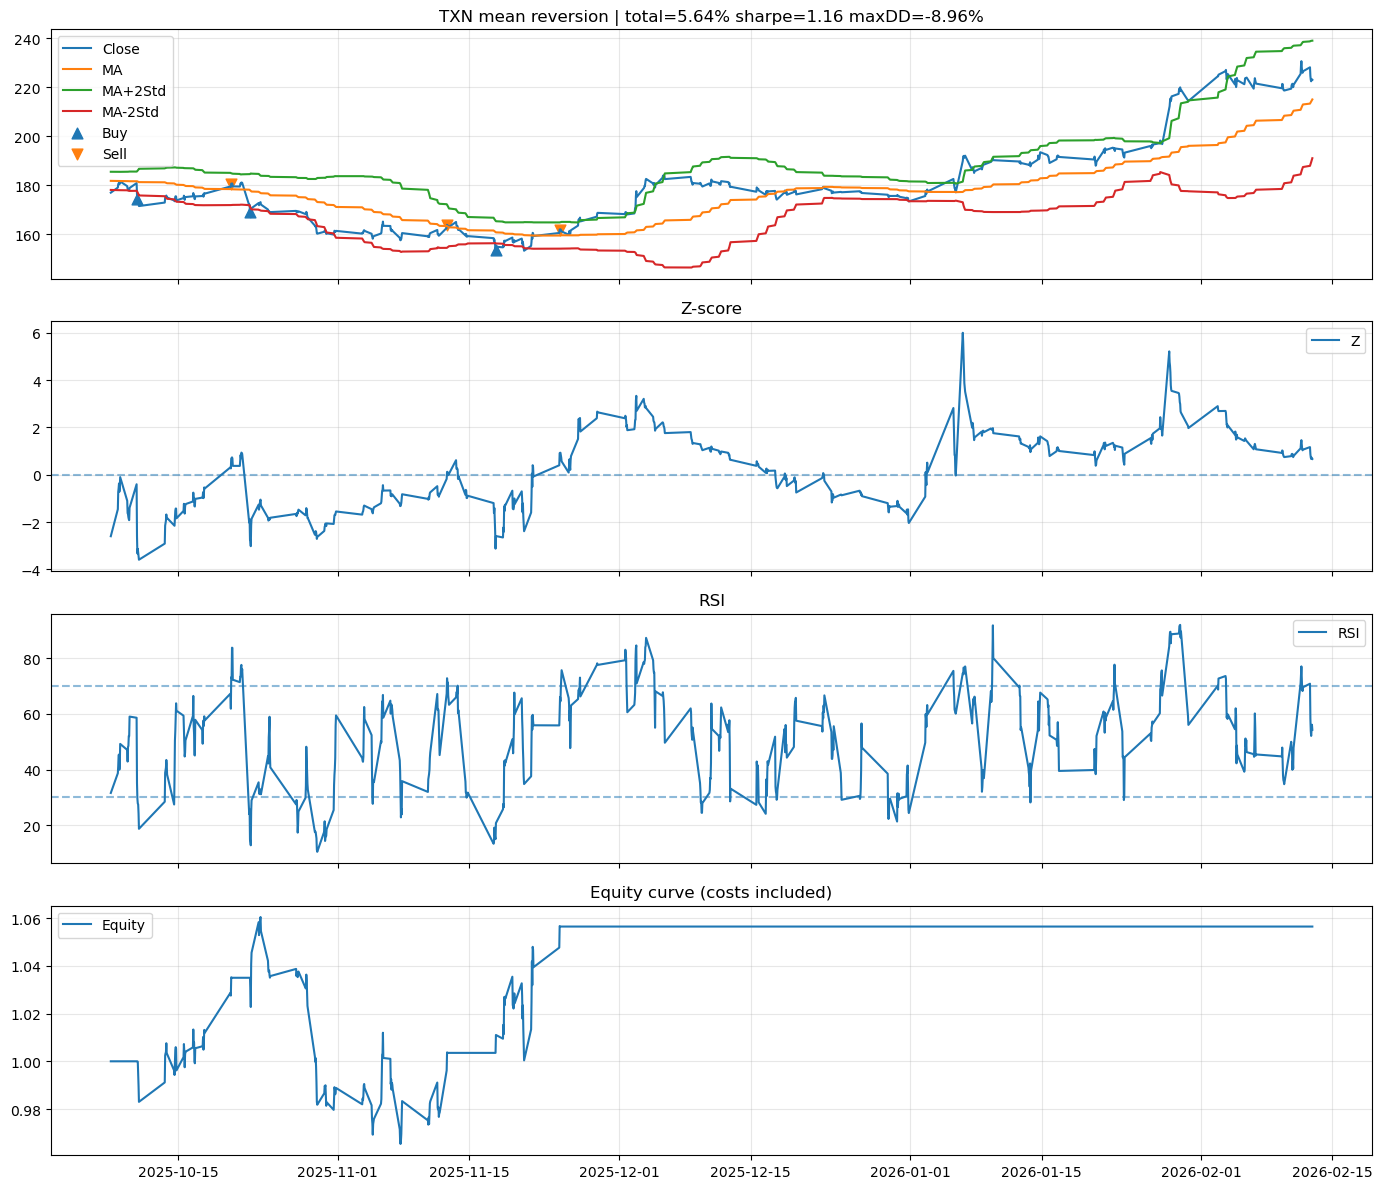

QCOM momentum best train sharpe 0.87 params {'lookback': 20, 'breakout_pct': 0.0, 'volume_mult': 1.5}


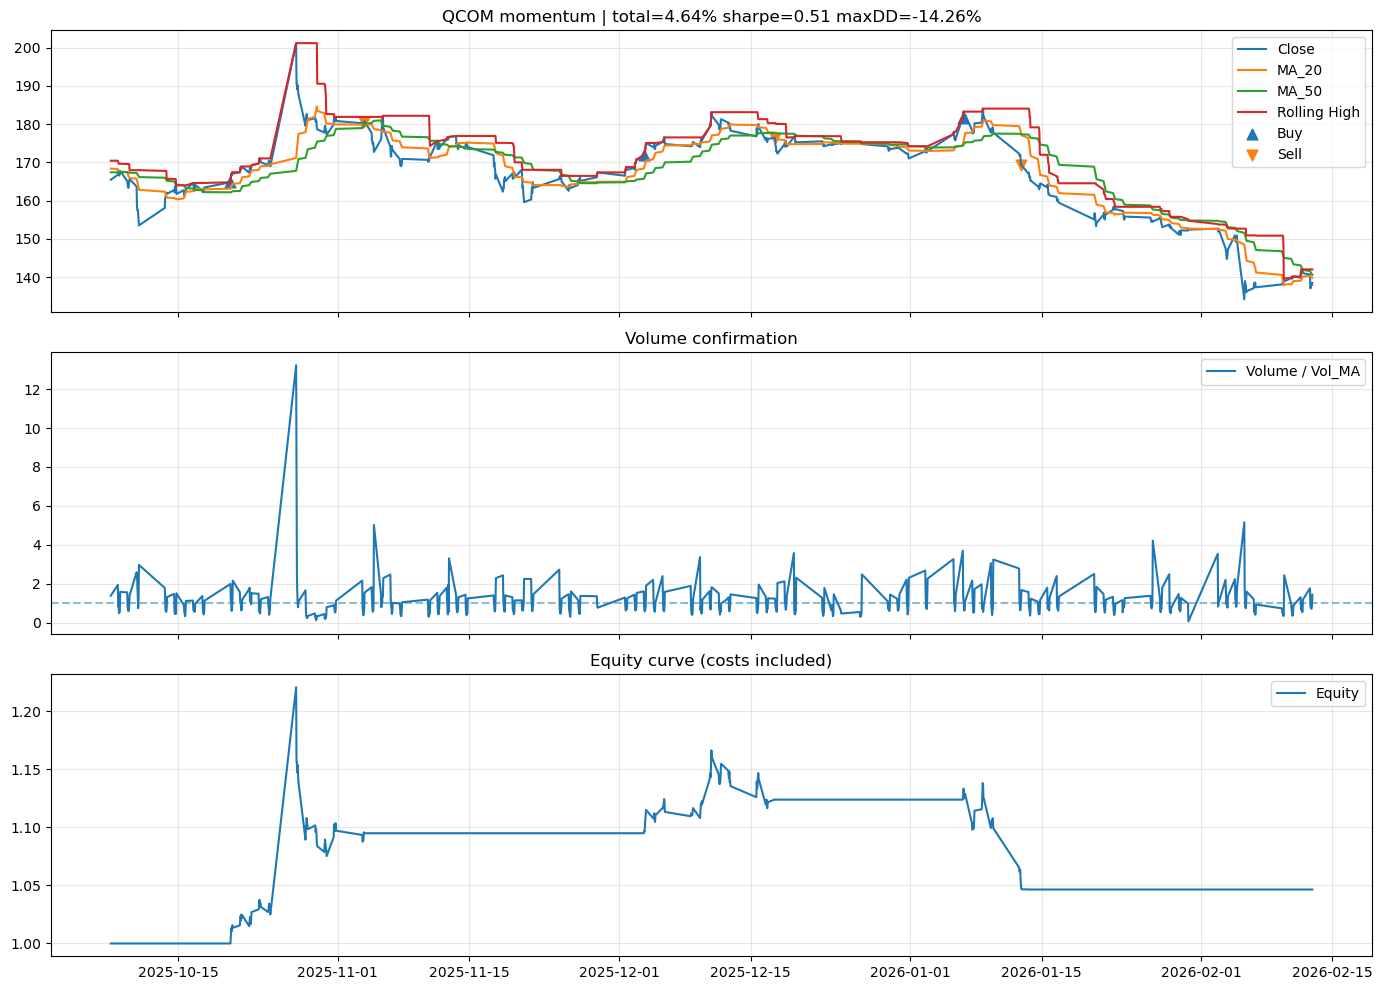

NVDA mean_reversion best train sharpe 2.75 params {'lookback': 100, 'entry_std': 1.5, 'exit_std': 0.5}


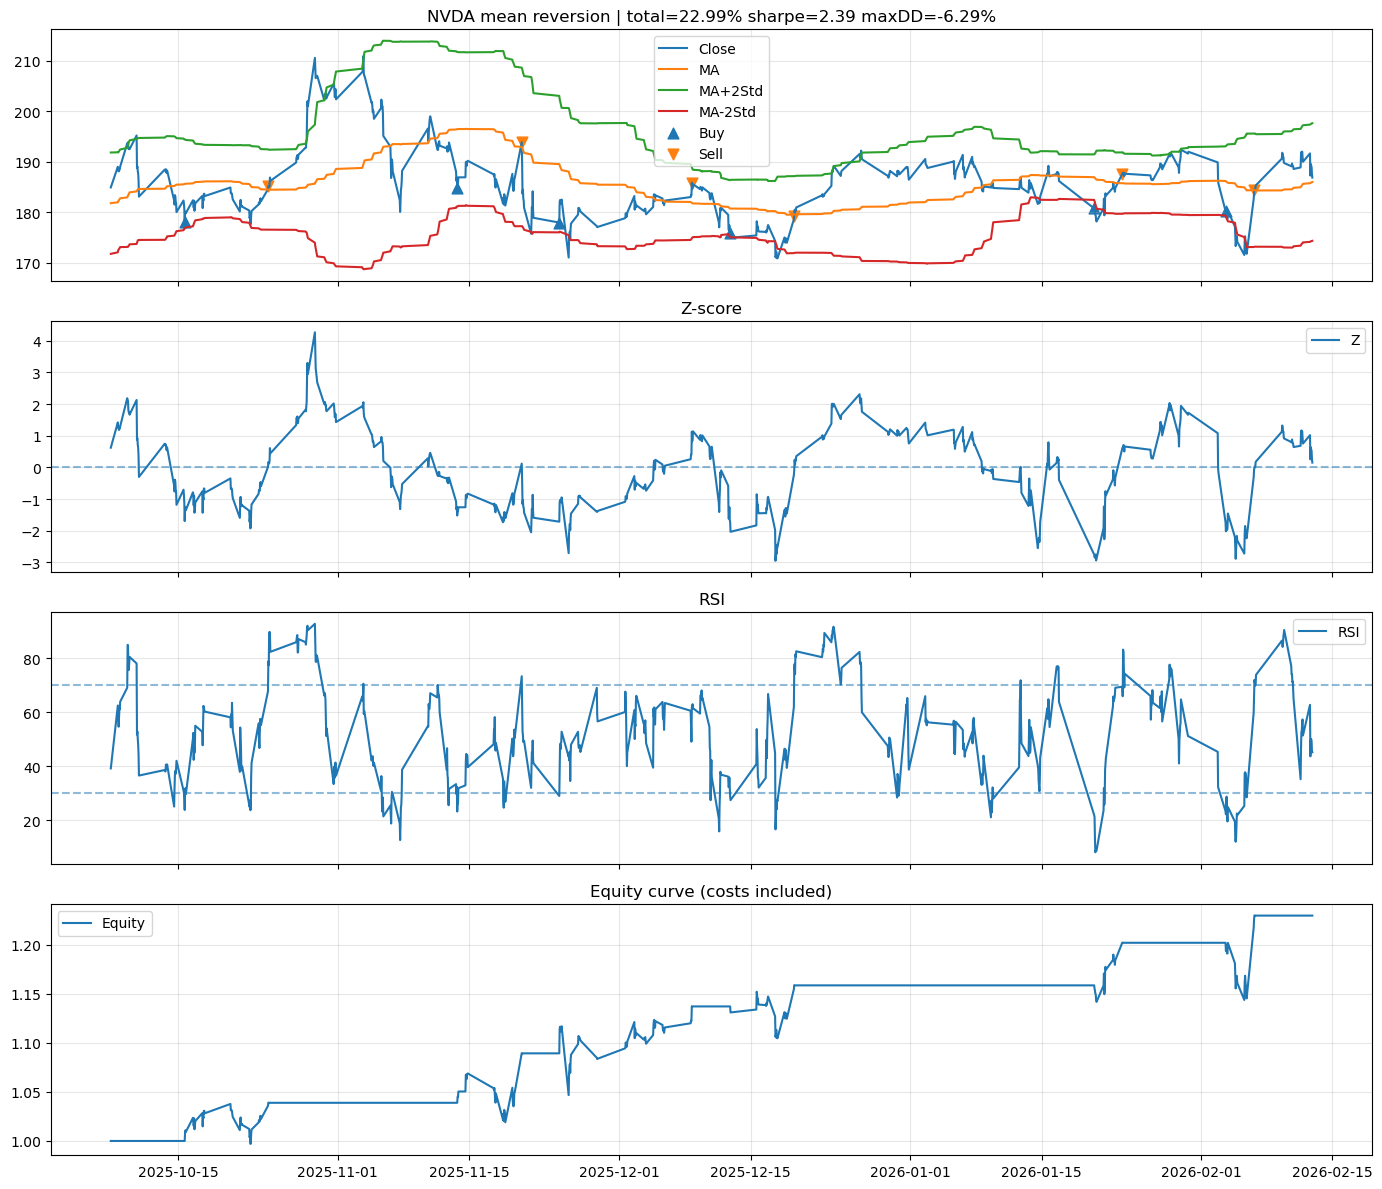

MSFT mean_reversion best train sharpe 1.43 params {'lookback': 40, 'entry_std': 2.0, 'exit_std': 1.0}


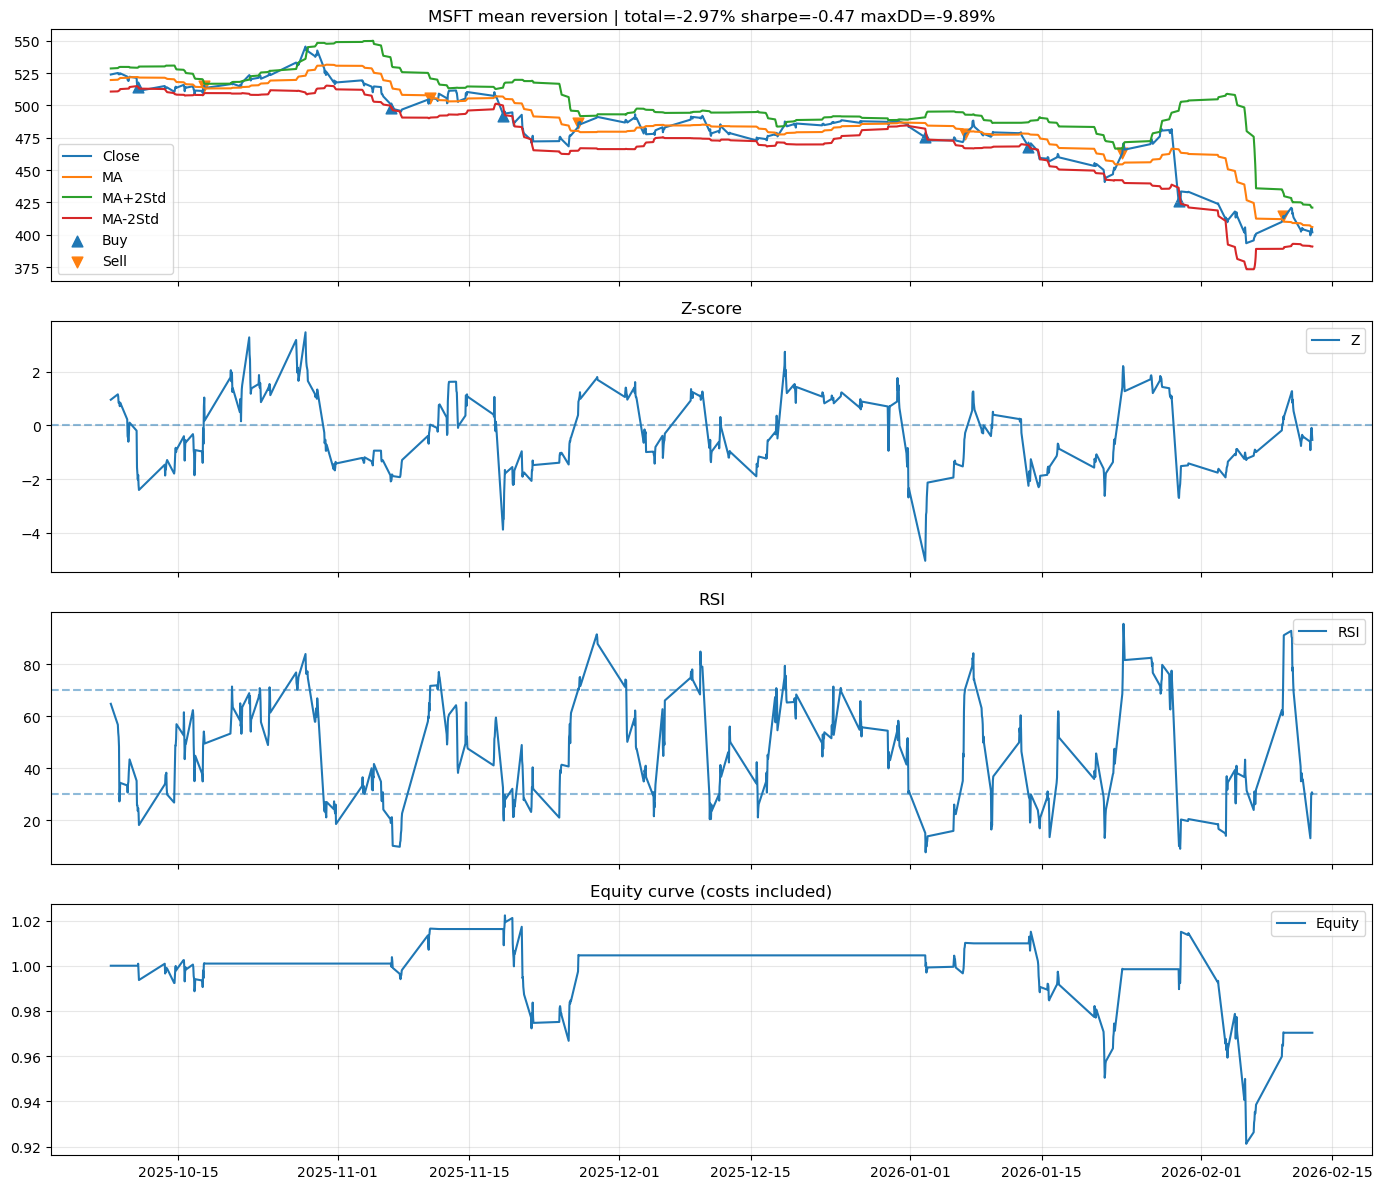

In [6]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# -------------------------
# Robust hourly downloader
# -------------------------
def download_hourly_ohlcv(ticker, period="6mo", interval="1h", prepost=False):
    df = yf.download(
        ticker,
        period=period,
        interval=interval,
        progress=False,
        auto_adjust=False,
        prepost=prepost,
        threads=True
    )
    if df is None or df.empty:
        return pd.DataFrame()

    df = df.sort_index()

    # Handle MultiIndex columns if yfinance returns (Field, Ticker)
    if isinstance(df.columns, pd.MultiIndex):
        # Common cases: ('Close', ticker) exists, or single-ticker but still MultiIndex
        if ("Close", ticker) in df.columns:
            out = pd.DataFrame(index=df.index)
            for col in ["Open", "High", "Low", "Close", "Adj Close", "Volume"]:
                if (col, ticker) in df.columns:
                    out[col] = df[(col, ticker)]
            df = out
        else:
            # Flatten by taking first level
            df.columns = df.columns.get_level_values(0)

    # Normalize close column
    if "Close" not in df.columns and "Adj Close" in df.columns:
        df["Close"] = df["Adj Close"]

    keep = [c for c in ["Open", "High", "Low", "Close", "Volume"] if c in df.columns]
    df = df[keep].copy()

    # Some symbols can have missing volume in certain feeds
    if "Volume" not in df.columns:
        df["Volume"] = np.nan

    df = df.dropna(subset=["Close"])
    return df


# -------------------------
# Indicators
# -------------------------
def calculate_rsi(close, period=14):
    delta = close.diff()
    gain = delta.where(delta > 0, 0.0).rolling(period).mean()
    loss = (-delta.where(delta < 0, 0.0)).rolling(period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))


# -------------------------
# Convert signals to long-flat positions
# signal = 1 means enter long
# signal = -1 means exit to flat
# -------------------------
def signals_to_positions_long_flat(signal):
    sig = signal.fillna(0).astype(int)
    pos = pd.Series(0.0, index=sig.index)
    in_pos = False
    for t in sig.index:
        if not in_pos and sig.loc[t] == 1:
            in_pos = True
        elif in_pos and sig.loc[t] == -1:
            in_pos = False
        pos.loc[t] = 1.0 if in_pos else 0.0
    return pos


def trade_points_from_positions(pos):
    p = pos.fillna(0.0)
    buys = p[(p.shift(1) == 0) & (p == 1)].index
    sells = p[(p.shift(1) == 1) & (p == 0)].index
    return buys, sells


# -------------------------
# Strategy feature builders
# These mirror your class logic, but return a single df with everything
# -------------------------
def build_momentum_features(df, lookback=20, breakout_pct=0.02, volume_mult=1.5):
    out = df.copy()
    out["MA_20"] = out["Close"].rolling(20).mean()
    out["MA_50"] = out["Close"].rolling(50).mean()
    out["High_lb"] = out["Close"].rolling(lookback).max()
    out["Vol_MA"] = out["Volume"].rolling(20).mean()

    # Signal: 1 enter, -1 exit
    sig = pd.Series(0, index=out.index)
    buy = (
        (out["Close"] > out["High_lb"].shift(1) * (1 + breakout_pct)) &
        (out["Volume"] > out["Vol_MA"] * volume_mult) &
        (out["MA_20"] > out["MA_50"]) &
        (out["Close"] > out["MA_20"])
    )
    sell = (
        (out["Close"] < out["MA_20"] * 0.95) |
        (out["MA_20"] < out["MA_50"])
    )
    sig.loc[buy] = 1
    sig.loc[sell] = -1

    out["Signal"] = sig
    out["Position"] = signals_to_positions_long_flat(out["Signal"])
    return out


def build_meanrev_features(df, lookback=20, entry_std=2.0, exit_std=0.5, rsi_period=14):
    out = df.copy()
    out["MA"] = out["Close"].rolling(lookback).mean()
    out["Std"] = out["Close"].rolling(lookback).std()
    out["Z"] = (out["Close"] - out["MA"]) / out["Std"]
    out["RSI"] = calculate_rsi(out["Close"], period=rsi_period)

    sig = pd.Series(0, index=out.index)
    buy = (out["Z"] < -entry_std) & (out["RSI"] < 30)
    sell = (out["Z"] > exit_std) | (out["RSI"] > 70)

    sig.loc[buy] = 1
    sig.loc[sell] = -1

    out["Signal"] = sig
    out["Position"] = signals_to_positions_long_flat(out["Signal"])
    return out


# -------------------------
# Backtest for parameter selection (simple)
# -------------------------
def backtest_long_flat(close, position, cost_bps=2.0):
    r = close.pct_change().fillna(0.0)
    pos = position.shift(1).fillna(0.0)

    turnover = pos.diff().abs().fillna(0.0)
    costs = turnover * (cost_bps / 10000.0)

    strat_r = pos * r - costs
    eq = (1 + strat_r).cumprod()
    total_ret = eq.iloc[-1] - 1.0
    vol = strat_r.std() * np.sqrt(252 * 6.5)
    ann = strat_r.mean() * (252 * 6.5)
    sharpe = 0.0 if vol == 0 else ann / vol
    max_dd = (eq / eq.cummax() - 1).min()
    return float(total_ret), float(sharpe), float(max_dd), eq


def optimize_params(ticker, strat_name, df, cost_bps=2.0, train_frac=0.7):
    n = len(df)
    split = int(n * train_frac)
    df_train = df.iloc[:split].copy()

    best = {"params": None, "sharpe": -1e9}

    if strat_name == "momentum":
        grid = []
        for lookback in [20, 40, 60, 100]:
            for breakout_pct in [0.0, 0.01, 0.02]:
                for volume_mult in [1.2, 1.5, 2.0]:
                    grid.append({"lookback": lookback, "breakout_pct": breakout_pct, "volume_mult": volume_mult})

        for p in grid:
            feat = build_momentum_features(df_train, **p)
            total_ret, sh, mdd, _ = backtest_long_flat(feat["Close"], feat["Position"], cost_bps=cost_bps)
            if sh > best["sharpe"]:
                best = {"params": p, "sharpe": sh}

    elif strat_name == "mean_reversion":
        grid = []
        for lookback in [20, 40, 60, 100]:
            for entry_std in [1.5, 2.0, 2.5]:
                for exit_std in [0.25, 0.5, 1.0]:
                    grid.append({"lookback": lookback, "entry_std": entry_std, "exit_std": exit_std})

        for p in grid:
            feat = build_meanrev_features(df_train, **p)
            total_ret, sh, mdd, _ = backtest_long_flat(feat["Close"], feat["Position"], cost_bps=cost_bps)
            if sh > best["sharpe"]:
                best = {"params": p, "sharpe": sh}

    else:
        raise ValueError("Unknown strategy name")

    return best


# -------------------------
# Plotting
# -------------------------
def plot_strategy(ticker, strat_name, feat, cost_bps=2.0, last_n=600):
    feat = feat.copy()
    if last_n is not None and len(feat) > last_n:
        feat = feat.iloc[-last_n:].copy()

    buys, sells = trade_points_from_positions(feat["Position"])
    total_ret, sh, mdd, eq = backtest_long_flat(feat["Close"], feat["Position"], cost_bps=cost_bps)

    if strat_name == "momentum":
        fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

        axes[0].plot(feat.index, feat["Close"], label="Close")
        axes[0].plot(feat.index, feat["MA_20"], label="MA_20")
        axes[0].plot(feat.index, feat["MA_50"], label="MA_50")
        axes[0].plot(feat.index, feat["High_lb"], label="Rolling High")
        axes[0].scatter(buys, feat.loc[buys, "Close"], marker="^", s=60, label="Buy")
        axes[0].scatter(sells, feat.loc[sells, "Close"], marker="v", s=60, label="Sell")
        axes[0].set_title(f"{ticker} momentum | total={total_ret:.2%} sharpe={sh:.2f} maxDD={mdd:.2%}")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        vol_ratio = feat["Volume"] / feat["Vol_MA"]
        axes[1].plot(feat.index, vol_ratio, label="Volume / Vol_MA")
        axes[1].axhline(1.0, linestyle="--", alpha=0.5)
        axes[1].set_title("Volume confirmation")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        axes[2].plot(eq.index, eq.values, label="Equity")
        axes[2].set_title("Equity curve (costs included)")
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    elif strat_name == "mean_reversion":
        fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

        axes[0].plot(feat.index, feat["Close"], label="Close")
        axes[0].plot(feat.index, feat["MA"], label="MA")
        axes[0].plot(feat.index, feat["MA"] + 2 * feat["Std"], label="MA+2Std")
        axes[0].plot(feat.index, feat["MA"] - 2 * feat["Std"], label="MA-2Std")
        axes[0].scatter(buys, feat.loc[buys, "Close"], marker="^", s=60, label="Buy")
        axes[0].scatter(sells, feat.loc[sells, "Close"], marker="v", s=60, label="Sell")
        axes[0].set_title(f"{ticker} mean reversion | total={total_ret:.2%} sharpe={sh:.2f} maxDD={mdd:.2%}")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(feat.index, feat["Z"], label="Z")
        axes[1].axhline(0, linestyle="--", alpha=0.5)
        axes[1].set_title("Z-score")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        axes[2].plot(feat.index, feat["RSI"], label="RSI")
        axes[2].axhline(30, linestyle="--", alpha=0.5)
        axes[2].axhline(70, linestyle="--", alpha=0.5)
        axes[2].set_title("RSI")
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

        axes[3].plot(eq.index, eq.values, label="Equity")
        axes[3].set_title("Equity curve (costs included)")
        axes[3].legend()
        axes[3].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("Unknown strategy name")


# -------------------------
# Run plots for your top combos
# -------------------------
top_combos = [
    ("TXN", "mean_reversion"),
    ("QCOM", "momentum"),
    ("NVDA", "mean_reversion"),
    ("MSFT", "mean_reversion"),
]

PERIOD = "6mo"
INTERVAL = "1h"
COST_BPS = 2.0
DO_OPTIMIZE = True   # set False to just use default params
LAST_N_BARS_TO_PLOT = 600

for ticker, strat_name in top_combos:
    df = download_hourly_ohlcv(ticker, period=PERIOD, interval=INTERVAL, prepost=False)
    if df.empty:
        print("No data for", ticker)
        continue

    # fill volume gaps lightly
    df["Volume"] = df["Volume"].fillna(method="ffill")

    if DO_OPTIMIZE:
        best = optimize_params(ticker, strat_name, df, cost_bps=COST_BPS, train_frac=0.7)
        params = best["params"]
        print(ticker, strat_name, "best train sharpe", round(best["sharpe"], 2), "params", params)
    else:
        params = None

    if strat_name == "momentum":
        if params is None:
            params = {"lookback": 20, "breakout_pct": 0.02, "volume_mult": 1.5}
        feat = build_momentum_features(df, **params)
    else:
        if params is None:
            params = {"lookback": 20, "entry_std": 2.0, "exit_std": 0.5}
        feat = build_meanrev_features(df, **params)

    plot_strategy(ticker, strat_name, feat, cost_bps=COST_BPS, last_n=LAST_N_BARS_TO_PLOT)


In [7]:
def summarize_segment(name, close, position, cost_bps=2.0):
    total_ret, sh, mdd, eq = backtest_long_flat(close, position, cost_bps=cost_bps)
    trades = count_trades(position)
    exposure = float(position.abs().mean())
    return {
        "segment": name,
        "total_return": total_ret,
        "sharpe": sh,
        "max_dd": mdd,
        "trades": trades,
        "exposure": exposure,
        "bars": len(close),
    }

def eval_train_test(ticker, strat_name, params, period="6mo", interval="1h", train_frac=0.7, cost_bps=2.0):
    df = download_hourly_ohlcv(ticker, period=period, interval=interval, prepost=False)
    if df.empty:
        print("No data for", ticker)
        return None

    df["Volume"] = df["Volume"].fillna(method="ffill")
    n = len(df)
    split = int(n * train_frac)

    df_train = df.iloc[:split].copy()
    df_test = df.iloc[split:].copy()

    if strat_name == "momentum":
        feat_train = build_momentum_features(df_train, **params)
        feat_test = build_momentum_features(df_test, **params)
    elif strat_name == "mean_reversion":
        feat_train = build_meanrev_features(df_train, **params)
        feat_test = build_meanrev_features(df_test, **params)
    else:
        raise ValueError("Unknown strategy")

    train_stats = summarize_segment("train", feat_train["Close"], feat_train["Position"], cost_bps=cost_bps)
    test_stats = summarize_segment("test", feat_test["Close"], feat_test["Position"], cost_bps=cost_bps)

    out = pd.DataFrame([train_stats, test_stats]).set_index("segment")
    print("\n", ticker, strat_name, "params", params)
    display(out)

    return out

chosen = [
    ("MSFT", "mean_reversion", {"lookback": 40, "entry_std": 2.0, "exit_std": 1.0}),
    ("NVDA", "mean_reversion", {"lookback": 100, "entry_std": 1.5, "exit_std": 0.5}),
    ("QCOM", "momentum", {"lookback": 20, "breakout_pct": 0.0, "volume_mult": 1.5}),
    ("TXN", "mean_reversion", {"lookback": 100, "entry_std": 2.5, "exit_std": 0.5}),
]

results = {}
for t, s, p in chosen:
    results[(t, s)] = eval_train_test(t, s, p, cost_bps=2.0)



 MSFT mean_reversion params {'lookback': 40, 'entry_std': 2.0, 'exit_std': 1.0}


,total_return,sharpe,max_dd,trades,exposure,bars
segment,,,,,,
train,0.047012,1.433036,-0.054275,10,0.234426,610
test,-0.034076,-1.039983,-0.092441,6,0.431298,262



 NVDA mean_reversion params {'lookback': 100, 'entry_std': 1.5, 'exit_std': 0.5}


,total_return,sharpe,max_dd,trades,exposure,bars
segment,,,,,,
train,0.228486,2.754675,-0.062860,9,0.288525,610
test,0.061421,1.905464,-0.048717,4,0.167939,262



 QCOM momentum params {'lookback': 20, 'breakout_pct': 0.0, 'volume_mult': 1.5}


,total_return,sharpe,max_dd,trades,exposure,bars
segment,,,,,,
train,0.098357,0.868563,-0.119097,7,0.373770,610
test,-0.068833,-3.371126,-0.080538,2,0.129771,262



 TXN mean_reversion params {'lookback': 100, 'entry_std': 2.5, 'exit_std': 0.5}


,total_return,sharpe,max_dd,trades,exposure,bars
segment,,,,,,
train,0.035201,0.664847,-0.089633,8,0.406557,610
test,0.000000,0.000000,0.000000,0,0.000000,262


In [8]:
def eval_combo(ticker, strat_name, cost_bps=2.0, train_frac=0.7, period="6mo", interval="1h"):
    df = download_hourly_ohlcv(ticker, period=period, interval=interval, prepost=False)
    if df.empty:
        return None

    df["Volume"] = df["Volume"].fillna(method="ffill")
    n = len(df)
    split = int(n * train_frac)
    if split < 300 or (n - split) < 120:
        return None

    df_train = df.iloc[:split].copy()
    df_test = df.iloc[split:].copy()

    best = optimize_params(ticker, strat_name, df, cost_bps=cost_bps, train_frac=train_frac)
    params = best["params"]
    if params is None:
        return None

    if strat_name == "momentum":
        feat_train = build_momentum_features(df_train, **params)
        feat_test = build_momentum_features(df_test, **params)
    else:
        feat_train = build_meanrev_features(df_train, **params)
        feat_test = build_meanrev_features(df_test, **params)

    tr_total, tr_sh, tr_mdd, _ = backtest_long_flat(feat_train["Close"], feat_train["Position"], cost_bps=cost_bps)
    te_total, te_sh, te_mdd, _ = backtest_long_flat(feat_test["Close"], feat_test["Position"], cost_bps=cost_bps)

    tr_trades = int(count_trades(feat_train["Position"]))
    te_trades = int(count_trades(feat_test["Position"]))
    tr_expo = float(feat_train["Position"].abs().mean())
    te_expo = float(feat_test["Position"].abs().mean())

    return {
        "ticker": ticker,
        "strategy": strat_name,
        "params": params,
        "train_total": tr_total,
        "train_sharpe": tr_sh,
        "train_maxdd": tr_mdd,
        "train_trades": tr_trades,
        "train_exposure": tr_expo,
        "test_total": te_total,
        "test_sharpe": te_sh,
        "test_maxdd": te_mdd,
        "test_trades": te_trades,
        "test_exposure": te_expo,
        "bars_total": n,
        "bars_train": split,
        "bars_test": n - split,
    }


def evaluate_universe(tickers, strategies=("mean_reversion", "momentum"), **kwargs):
    rows = []
    for t in tickers:
        for s in strategies:
            res = eval_combo(t, s, **kwargs)
            if res is not None:
                rows.append(res)

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows)

    # filter out "did nothing" in test
    df = df[df["test_trades"] > 0].copy()

    # Sort by test performance. You can choose test_total if you only care about max return.
    df = df.sort_values(["test_sharpe", "test_total"], ascending=False).reset_index(drop=True)
    return df


In [10]:
# Example: use your screened tickers
# screened_tickers = [stock["ticker"] for stock in results]
tickers_to_test = ["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "QCOM", "TXN", "UPS", "DIS"]  # replace if needed

rank_df = evaluate_universe(
    tickers_to_test,
    strategies=("mean_reversion", "momentum"),
    cost_bps=2.0,
    train_frac=0.7,
    period="6mo",
    interval="1h"
)

display(rank_df.head(15)[[
    "ticker","strategy","test_total","test_sharpe","test_maxdd","test_trades","test_exposure",
    "train_sharpe","train_total","params"
]])


,ticker,strategy,test_total,test_sharpe,test_maxdd,test_trades,test_exposure,train_sharpe,train_total,params
0,TXN,momentum,0.148270,3.256995,-0.037109,2,0.446565,2.213109,0.071207,"{'lookback': 100, 'breakout_pct': 0.0, 'volume..."
1,NVDA,mean_reversion,0.061421,1.905464,-0.048717,4,0.167939,2.754675,0.228486,"{'lookback': 100, 'entry_std': 1.5, 'exit_std'..."
2,DIS,mean_reversion,0.042020,1.732127,-0.029538,3,0.171756,2.172910,0.063055,"{'lookback': 40, 'entry_std': 2.5, 'exit_std':..."
3,GOOGL,mean_reversion,0.014396,0.651838,-0.069937,3,0.251908,2.855496,0.130644,"{'lookback': 60, 'entry_std': 1.5, 'exit_std':..."
4,AAPL,mean_reversion,-0.011156,-0.582930,-0.052240,5,0.290076,3.151291,0.108302,"{'lookback': 60, 'entry_std': 2.0, 'exit_std':..."
5,MSFT,mean_reversion,-0.034076,-1.039983,-0.092441,6,0.431298,1.433036,0.047012,"{'lookback': 40, 'entry_std': 2.0, 'exit_std':..."
6,GOOGL,momentum,-0.035762,-1.041753,-0.099467,4,0.427481,2.731365,0.298594,"{'lookback': 20, 'breakout_pct': 0.0, 'volume_..."
7,AAPL,momentum,-0.036350,-2.075488,-0.049396,2,0.164122,1.426351,0.059470,"{'lookback': 100, 'breakout_pct': 0.0, 'volume..."
8,UPS,momentum,-0.039544,-2.171846,-0.062158,3,0.221374,0.765667,0.038280,"{'lookback': 100, 'breakout_pct': 0.01, 'volum..."
9,AMZN,mean_reversion,-0.102846,-2.819620,-0.119868,1,0.160305,1.374236,0.033219,"{'lookback': 100, 'entry_std': 2.5, 'exit_std'..."



Plotting: TXN momentum params: {'lookback': 100, 'breakout_pct': 0.0, 'volume_mult': 1.2} test_total: 0.1483 test_sharpe: 3.26 test_trades: 2


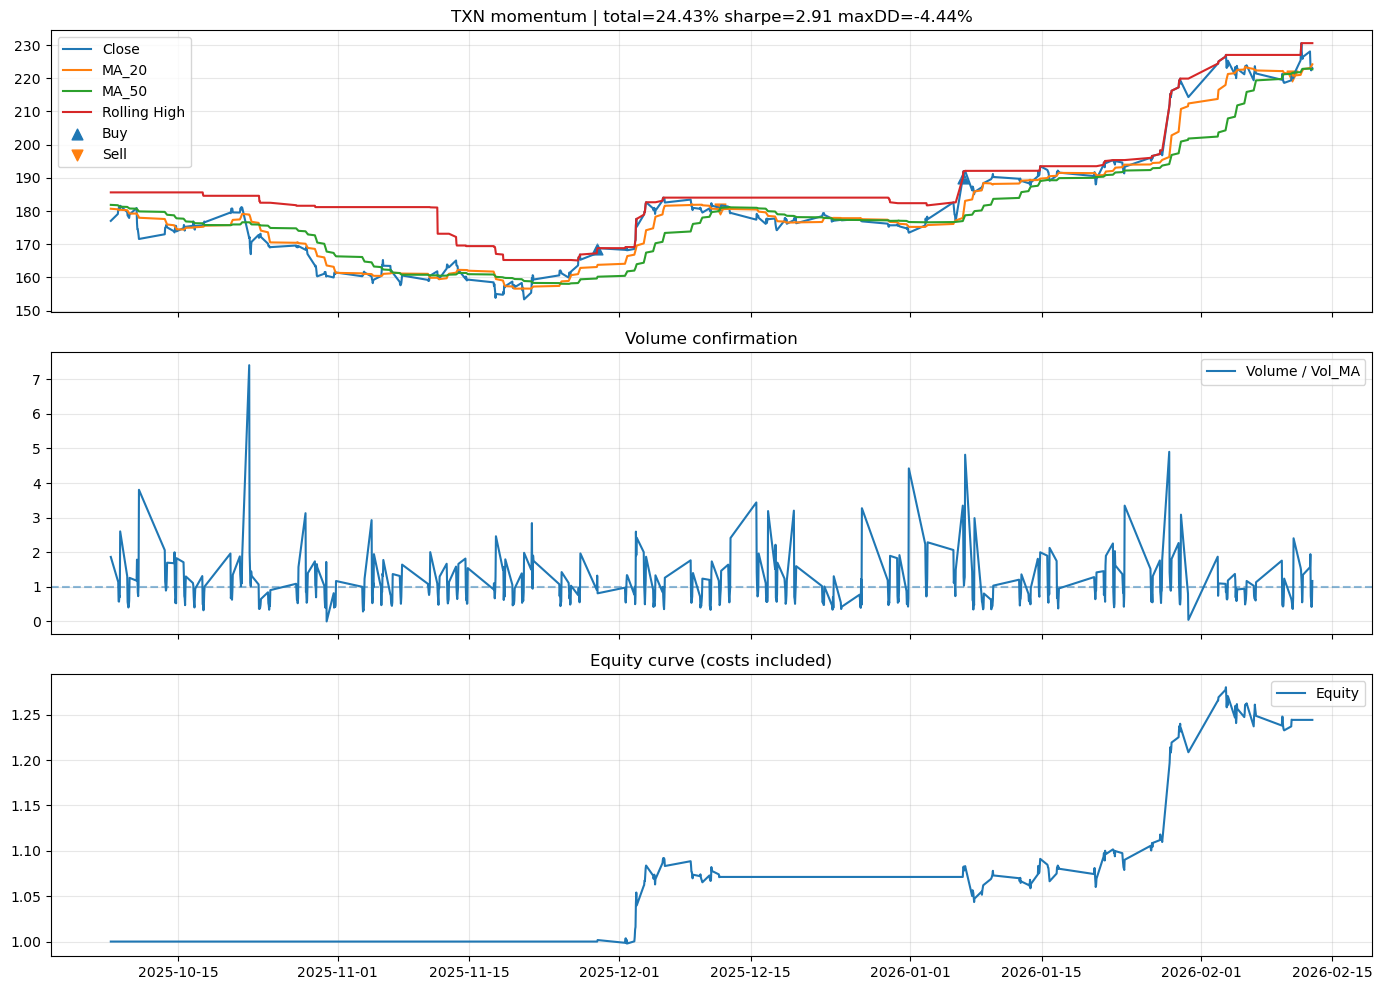


Plotting: NVDA mean_reversion params: {'lookback': 100, 'entry_std': 1.5, 'exit_std': 0.5} test_total: 0.0614 test_sharpe: 1.91 test_trades: 4


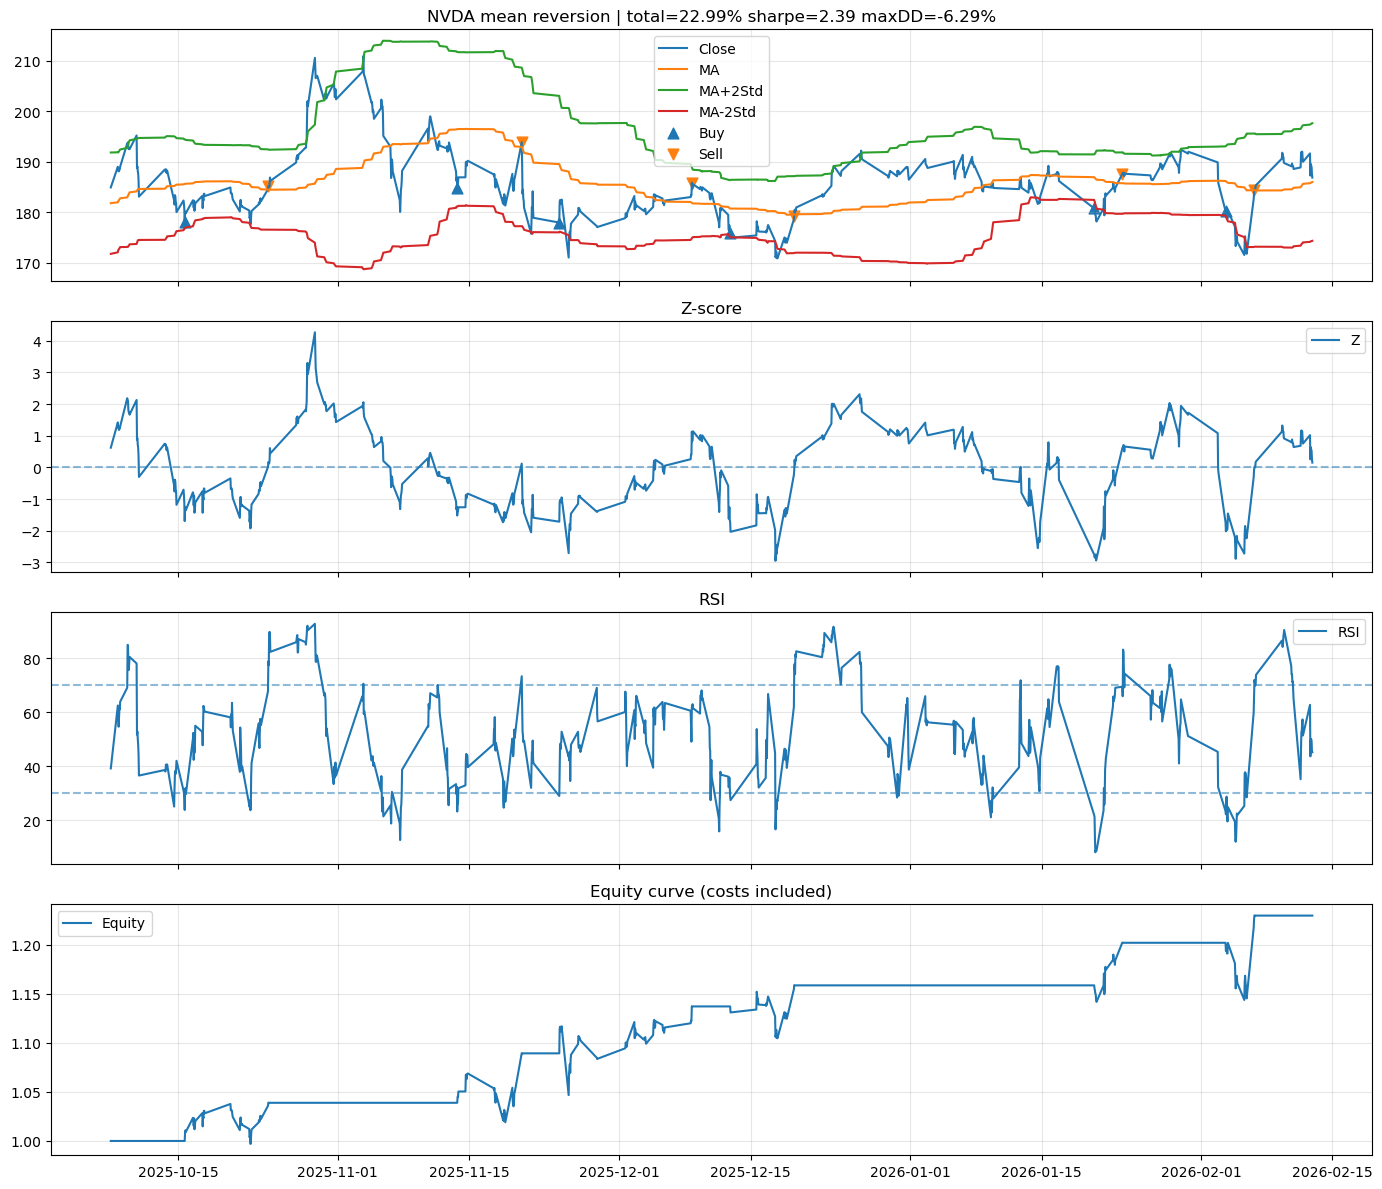


Plotting: DIS mean_reversion params: {'lookback': 40, 'entry_std': 2.5, 'exit_std': 1.0} test_total: 0.042 test_sharpe: 1.73 test_trades: 3


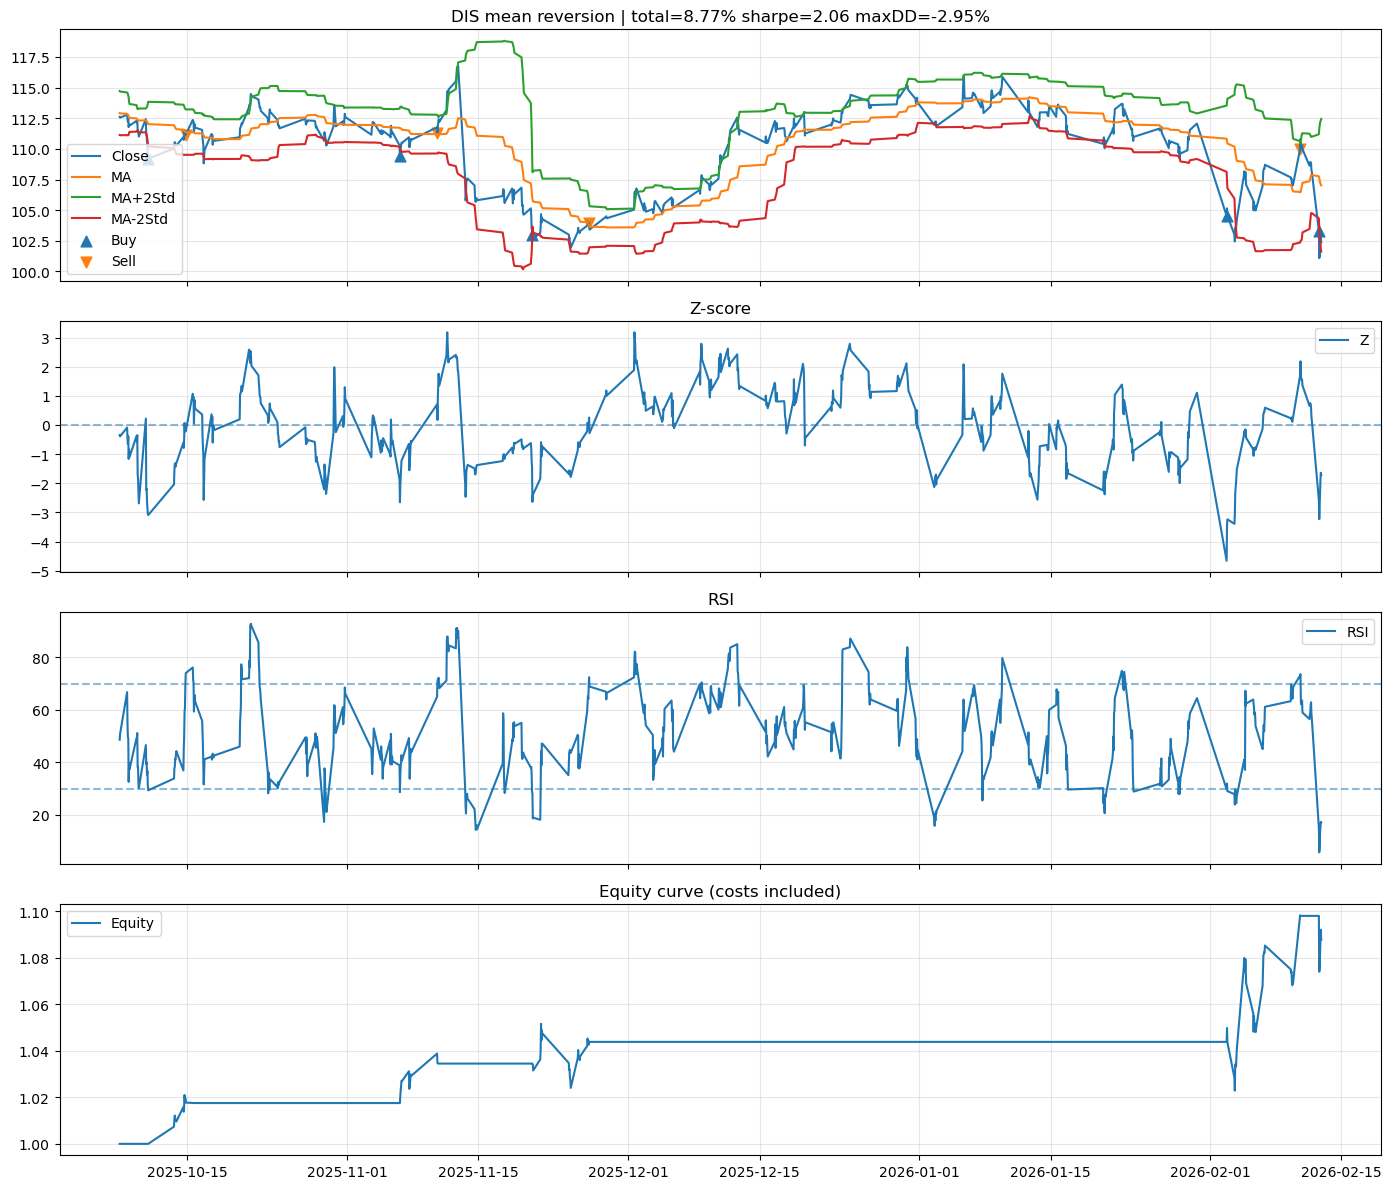


Plotting: GOOGL mean_reversion params: {'lookback': 60, 'entry_std': 1.5, 'exit_std': 0.5} test_total: 0.0144 test_sharpe: 0.65 test_trades: 3


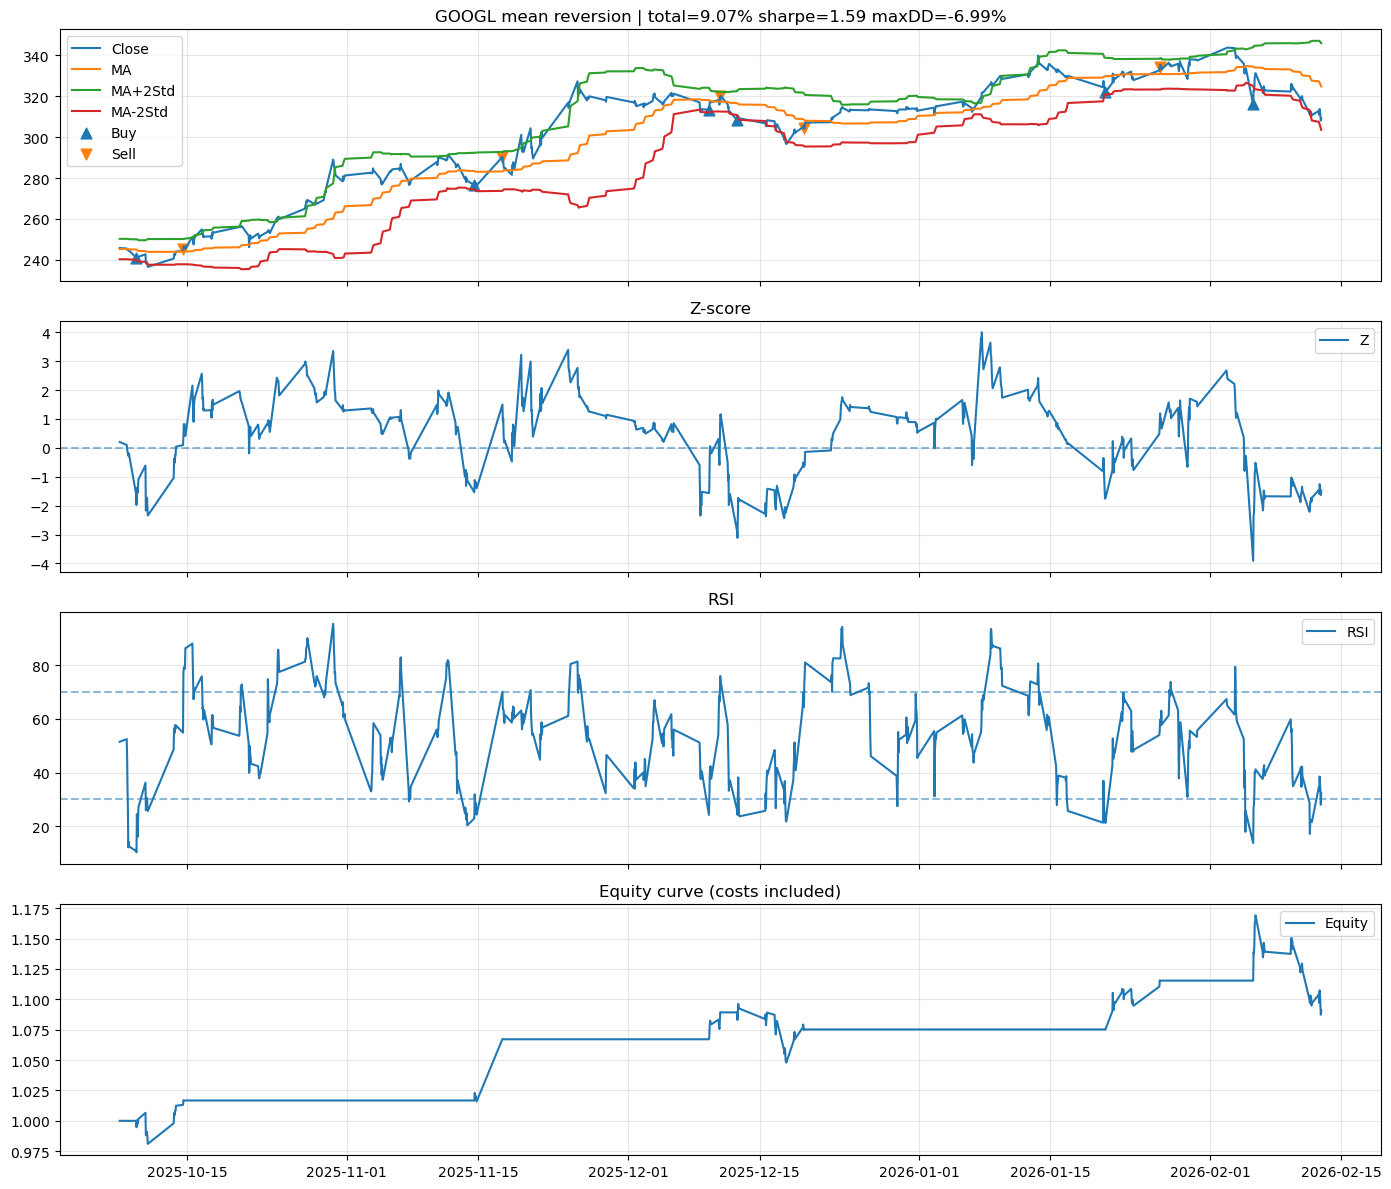


Plotting: AAPL mean_reversion params: {'lookback': 60, 'entry_std': 2.0, 'exit_std': 0.5} test_total: -0.0112 test_sharpe: -0.58 test_trades: 5


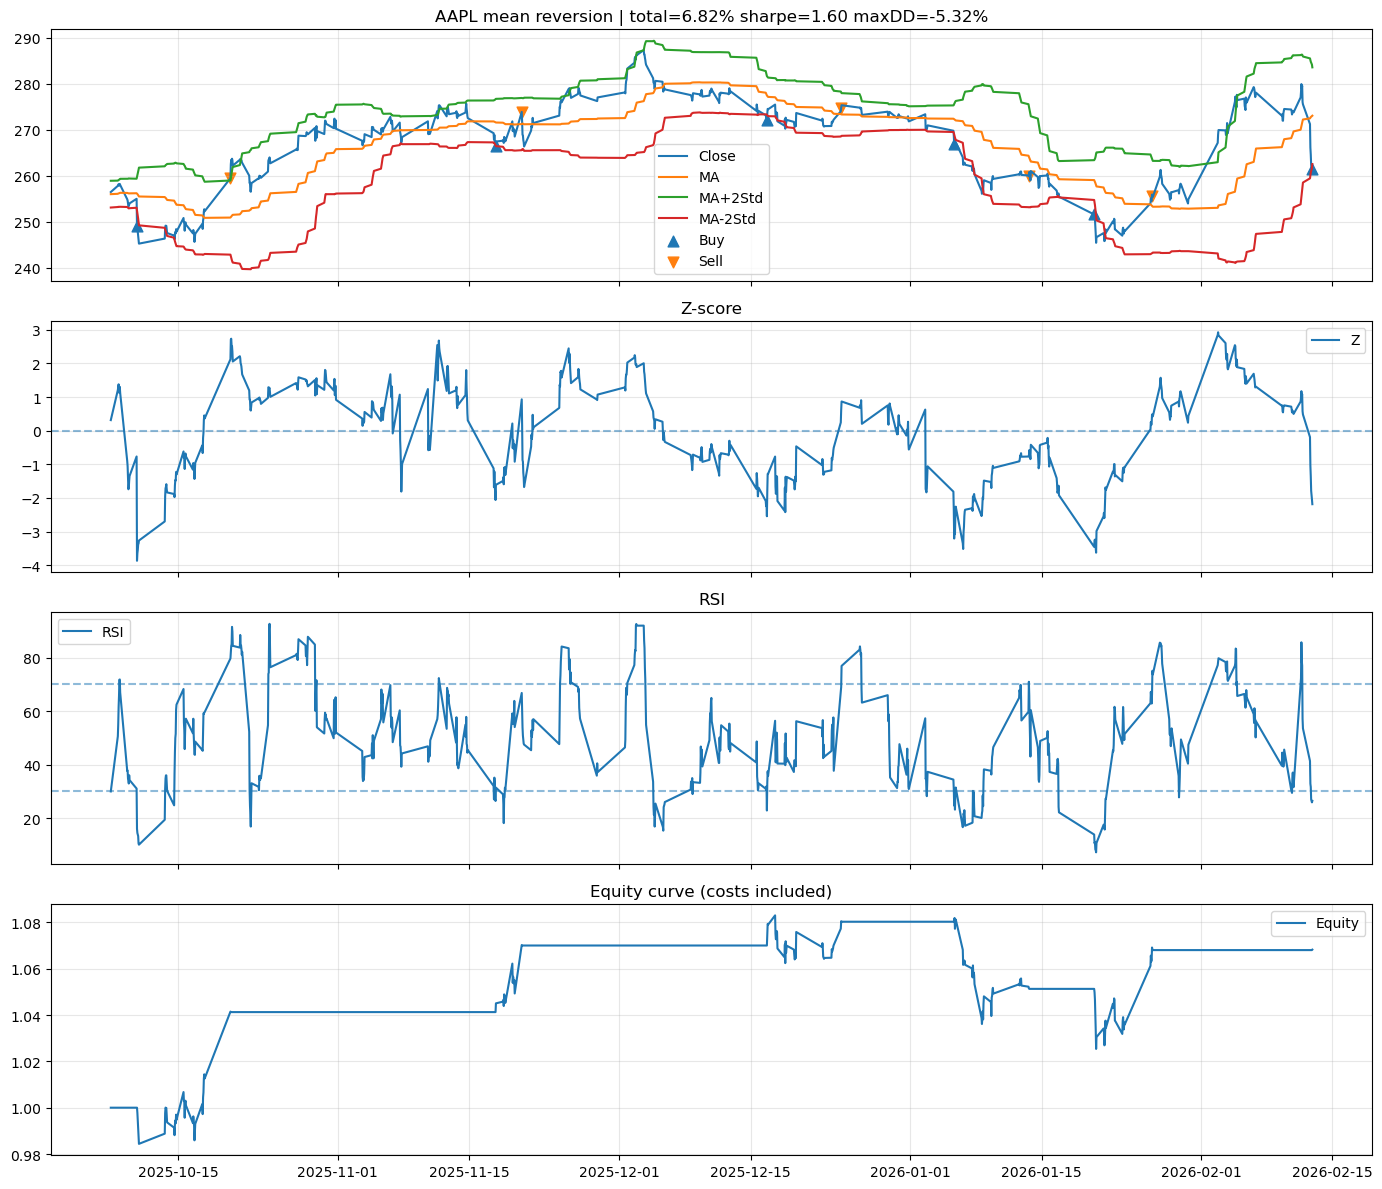

In [11]:
def build_features_for_plot(df, strat_name, params):
    if strat_name == "momentum":
        return build_momentum_features(df, **params)
    return build_meanrev_features(df, **params)

def plot_top_from_ranking(rank_df, top_n=5, cost_bps=2.0, period="6mo", interval="1h", last_n=600):
    top = rank_df.head(top_n).copy()
    for _, row in top.iterrows():
        ticker = row["ticker"]
        strat = row["strategy"]
        params = row["params"]

        df = download_hourly_ohlcv(ticker, period=period, interval=interval, prepost=False)
        if df.empty:
            print("No data for", ticker)
            continue
        df["Volume"] = df["Volume"].fillna(method="ffill")

        feat = build_features_for_plot(df, strat, params)
        print("\nPlotting:", ticker, strat, "params:", params,
              "test_total:", round(row["test_total"], 4),
              "test_sharpe:", round(row["test_sharpe"], 2),
              "test_trades:", int(row["test_trades"]))

        plot_strategy(ticker, strat, feat, cost_bps=cost_bps, last_n=last_n)

plot_top_from_ranking(rank_df, top_n=5, cost_bps=2.0, period="6mo", interval="1h", last_n=600)


In [12]:
import itertools
import numpy as np
import pandas as pd

def param_grid(grid_dict):
    keys = list(grid_dict.keys())
    vals = [grid_dict[k] for k in keys]
    for combo in itertools.product(*vals):
        yield dict(zip(keys, combo))

def walk_forward_with_features(
    ticker,
    strat_name,
    build_func,          # build_momentum_features or build_meanrev_features
    grid_dict,
    period="6mo",
    interval="1h",
    prepost=False,
    train_bars=500,
    test_bars=130,
    step_bars=130,
    cost_bps=2.0,
    min_trades_train=3,
    min_exposure_train=0.03,
):
    df = download_hourly_ohlcv(ticker, period=period, interval=interval, prepost=prepost)
    if df.empty:
        return None

    df["Volume"] = df["Volume"].fillna(method="ffill")

    idx = df.index
    n = len(df)
    if n < train_bars + test_bars + 20:
        return None

    oos_returns = []
    chosen = []

    start = 0
    while True:
        tr_start = start
        tr_end = tr_start + train_bars
        te_end = tr_end + test_bars
        if te_end > n:
            break

        df_train = df.iloc[tr_start:tr_end].copy()
        df_test = df.iloc[tr_end:te_end].copy()

        best_p = None
        best_sh = -1e9

        # select params on train
        for p in param_grid(grid_dict):
            feat_tr = build_func(df_train, **p)
            pos_tr = feat_tr["Position"].fillna(0.0)

            trades_tr = int(count_trades(pos_tr))
            expo_tr = float(pos_tr.abs().mean())
            if trades_tr < min_trades_train or expo_tr < min_exposure_train:
                continue

            total_ret_tr, sh_tr, mdd_tr, eq_tr = backtest_long_flat(feat_tr["Close"], pos_tr, cost_bps=cost_bps)
            if sh_tr > best_sh:
                best_sh = sh_tr
                best_p = p

        if best_p is None:
            start += step_bars
            continue

        # trade test with chosen params
        feat_te = build_func(df_test, **best_p)
        pos_te = feat_te["Position"].fillna(0.0)
        strat_te = backtest_long_flat(feat_te["Close"], pos_te, cost_bps=cost_bps)[3].pct_change().fillna(0.0)

        # alternative: use the return series directly (more correct)
        # recompute returns from position and close
        r_te = feat_te["Close"].pct_change().fillna(0.0)
        pos_lag = pos_te.shift(1).fillna(0.0)
        turnover = pos_lag.diff().abs().fillna(0.0)
        costs = turnover * (cost_bps / 10000.0)
        strat_r_te = pos_lag * r_te - costs

        oos_returns.append(strat_r_te)
        chosen.append({"window_start": str(df_test.index[0]), "best_params": best_p, "train_sharpe": float(best_sh)})

        start += step_bars

    if not oos_returns:
        return None

    oos = pd.concat(oos_returns).sort_index()
    eq = (1 + oos).cumprod()
    total_return = float(eq.iloc[-1] - 1.0)
    max_dd = float((eq / eq.cummax() - 1).min())
    vol = oos.std() * np.sqrt(252 * 6.5)
    ann = oos.mean() * (252 * 6.5)
    sharpe = 0.0 if vol == 0 else float(ann / vol)

    return {
        "ticker": ticker,
        "strategy": strat_name,
        "oos_total_return": total_return,
        "oos_sharpe": sharpe,
        "oos_max_dd": max_dd,
        "oos_bars": len(oos),
        "chosen_windows": chosen,
        "oos_returns": oos,
    }


In [13]:
mr_grid = {
    "lookback": [40, 60, 100],
    "entry_std": [1.5, 2.0, 2.5],
    "exit_std": [0.25, 0.5, 1.0],
}

res = walk_forward_with_features(
    ticker="NVDA",
    strat_name="mean_reversion",
    build_func=build_meanrev_features,
    grid_dict=mr_grid,
    train_bars=500,
    test_bars=130,
    step_bars=130,
    cost_bps=2.0,
)

print(res["ticker"], res["strategy"], res["oos_total_return"], res["oos_sharpe"], res["oos_max_dd"])


NVDA mean_reversion 0.03917697819289989 2.5539607276550034 -0.007947277769473238


In [14]:
import pandas as pd

tickers_to_test = ["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "QCOM", "TXN", "UPS", "DIS"]

# Parameter grids (keep these modest so it runs fast in a notebook)
mr_grid = {
    "lookback": [40, 60, 100],
    "entry_std": [1.5, 2.0, 2.5],
    "exit_std": [0.25, 0.5, 1.0],
}

mom_grid = {
    "lookback": [20, 40, 60],
    "breakout_pct": [0.0, 0.01, 0.02],
    "volume_mult": [1.2, 1.5, 2.0],
}

def run_universe_wf(tickers, cost_bps=2.0):
    rows = []
    store = {}  # keep full objects for later plotting if needed

    for t in tickers:
        # Mean Reversion
        r_mr = walk_forward_with_features(
            ticker=t,
            strat_name="mean_reversion",
            build_func=build_meanrev_features,
            grid_dict=mr_grid,
            train_bars=500,
            test_bars=130,
            step_bars=130,
            cost_bps=cost_bps,
            min_trades_train=3,
            min_exposure_train=0.03,
        )
        if r_mr is not None:
            rows.append({
                "ticker": t,
                "strategy": "mean_reversion",
                "oos_total_return": r_mr["oos_total_return"],
                "oos_sharpe": r_mr["oos_sharpe"],
                "oos_max_dd": r_mr["oos_max_dd"],
                "oos_bars": r_mr["oos_bars"],
                "n_windows": len(r_mr["chosen_windows"]),
            })
            store[(t, "mean_reversion")] = r_mr

        # Momentum
        r_mom = walk_forward_with_features(
            ticker=t,
            strat_name="momentum",
            build_func=build_momentum_features,
            grid_dict=mom_grid,
            train_bars=500,
            test_bars=130,
            step_bars=130,
            cost_bps=cost_bps,
            min_trades_train=3,
            min_exposure_train=0.03,
        )
        if r_mom is not None:
            rows.append({
                "ticker": t,
                "strategy": "momentum",
                "oos_total_return": r_mom["oos_total_return"],
                "oos_sharpe": r_mom["oos_sharpe"],
                "oos_max_dd": r_mom["oos_max_dd"],
                "oos_bars": r_mom["oos_bars"],
                "n_windows": len(r_mom["chosen_windows"]),
            })
            store[(t, "momentum")] = r_mom

    df = pd.DataFrame(rows)
    if df.empty:
        return df, store

    df = df.sort_values(["oos_total_return", "oos_sharpe"], ascending=False).reset_index(drop=True)
    return df, store

rank_df, wf_store = run_universe_wf(tickers_to_test, cost_bps=2.0)

display(rank_df)


,ticker,strategy,oos_total_return,oos_sharpe,oos_max_dd,oos_bars,n_windows
0,UPS,momentum,0.056491,3.224879,-0.022093,260,2
1,NVDA,mean_reversion,0.039177,2.553961,-0.007947,260,2
2,AAPL,momentum,0.000000,0.000000,0.000000,260,2
3,MSFT,momentum,0.000000,0.000000,0.000000,260,2
4,AMZN,mean_reversion,0.000000,0.000000,0.000000,260,2
5,TXN,mean_reversion,0.000000,0.000000,0.000000,260,2
6,UPS,mean_reversion,0.000000,0.000000,0.000000,260,2
7,DIS,mean_reversion,0.000000,0.000000,0.000000,260,2
8,GOOGL,momentum,-0.000247,0.027687,-0.045484,260,2
9,TXN,momentum,-0.010358,-0.491741,-0.036623,260,2


In [15]:
def backtest_returns_series(close, position, cost_bps=2.0):
    r = close.pct_change().fillna(0.0)
    pos = position.shift(1).fillna(0.0)
    turnover = pos.diff().abs().fillna(0.0)
    costs = turnover * (cost_bps / 10000.0)
    return pos * r - costs

def window_trade_exposure_report(ticker, strat_name, build_func, grid_dict,
                                 train_bars=500, test_bars=130, step_bars=130,
                                 period="6mo", interval="1h", cost_bps=2.0):
    df = download_hourly_ohlcv(ticker, period=period, interval=interval, prepost=False)
    df["Volume"] = df["Volume"].fillna(method="ffill")
    n = len(df)

    start = 0
    k = 0
    while True:
        tr_end = start + train_bars
        te_end = tr_end + test_bars
        if te_end > n:
            break

        df_train = df.iloc[start:tr_end].copy()
        df_test = df.iloc[tr_end:te_end].copy()

        best_p = None
        best_sh = -1e9

        for p in param_grid(grid_dict):
            feat_tr = build_func(df_train, **p)
            pos_tr = feat_tr["Position"].fillna(0.0)
            if int(count_trades(pos_tr)) < 3 or float(pos_tr.abs().mean()) < 0.03:
                continue
            ret_tr = backtest_returns_series(feat_tr["Close"], pos_tr, cost_bps=cost_bps)
            vol = ret_tr.std() * np.sqrt(252 * 6.5)
            ann = ret_tr.mean() * (252 * 6.5)
            sh = 0.0 if vol == 0 else float(ann / vol)
            if sh > best_sh:
                best_sh = sh
                best_p = p

        feat_te = build_func(df_test, **best_p)
        pos_te = feat_te["Position"].fillna(0.0)
        ret_te = backtest_returns_series(feat_te["Close"], pos_te, cost_bps=cost_bps)

        k += 1
        print("\n", ticker, strat_name, "window", k)
        print("test_start:", df_test.index[0], "test_end:", df_test.index[-1])
        print("best_params:", best_p, "train_sharpe:", round(best_sh, 2))
        print("test_trades:", int(count_trades(pos_te)), "test_exposure:", round(float(pos_te.abs().mean()), 3))
        print("test_total_return:", round(float((1 + ret_te).prod() - 1), 4))

        start += step_bars

# Run for your two winners
window_trade_exposure_report("UPS", "momentum", build_momentum_features, mom_grid)
window_trade_exposure_report("NVDA", "mean_reversion", build_meanrev_features, mr_grid)



 UPS momentum window 1
test_start: 2025-11-21 17:30:00+00:00 test_end: 2025-12-19 17:30:00+00:00
best_params: {'lookback': 20, 'breakout_pct': 0.0, 'volume_mult': 1.2} train_sharpe: 0.39
test_trades: 1 test_exposure: 0.408
test_total_return: 0.0287

 UPS momentum window 2
test_start: 2025-12-19 18:30:00+00:00 test_end: 2026-01-20 18:30:00+00:00
best_params: {'lookback': 20, 'breakout_pct': 0.0, 'volume_mult': 1.2} train_sharpe: 1.01
test_trades: 2 test_exposure: 0.508
test_total_return: 0.027

 NVDA mean_reversion window 1
test_start: 2025-11-21 17:30:00+00:00 test_end: 2025-12-19 17:30:00+00:00
best_params: {'lookback': 100, 'entry_std': 1.5, 'exit_std': 0.25} train_sharpe: 3.13
test_trades: 2 test_exposure: 0.108
test_total_return: 0.0473

 NVDA mean_reversion window 2
test_start: 2025-12-19 18:30:00+00:00 test_end: 2026-01-20 18:30:00+00:00
best_params: {'lookback': 40, 'entry_std': 2.0, 'exit_std': 0.25} train_sharpe: 2.24
test_trades: 1 test_exposure: 0.038
test_total_return: -0.